<a href="https://colab.research.google.com/github/behraj/workshops/blob/main/Pneumonia_Frozen_Baselines_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pneumonia Detection - Frozen Feature Extractors

## Two Frozen Baseline Models:
1. **ResNet-50**: ImageNet pre-trained, outputs 2048-dim features
2. **DINO ViT-S/14**: Self-supervised, outputs 384-dim features

### Features:
- Input: 224×224 RGB chest X-ray images
- Purely frozen models (no training)
- Extract features for downstream analysis
- Dataset: Chest X-Ray Pneumonia (Kaggle)

---

## 1. Setup & GPU Check

In [ ]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ No GPU found - extraction will be slower on CPU")

PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla T4
GPU Memory: 15.64 GB


In [ ]:
!pip install -q torch torchvision
!pip install -q scikit-learn matplotlib Pillow tqdm
!pip install -q kagglehub

print("✓ All packages installed successfully!")

✓ All packages installed successfully!


## 2. Download Dataset from Kaggle

In [ ]:
import kagglehub

# Download chest X-ray pneumonia dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
import os
from pathlib import Path

# The Kaggle dataset structure: chest_xray/train, chest_xray/test, chest_xray/val
# Each contains NORMAL/ and PNEUMONIA/ subdirectories

data_root = Path(path) / 'chest_xray'

print("Dataset structure:")
print("="*60)

for split in ['train', 'test', 'val']:
    split_path = data_root / split
    if split_path.exists():
        print(f"\n{split.upper()} SET:")
        for class_dir in split_path.iterdir():
            if class_dir.is_dir():
                n_images = len(list(class_dir.glob('*.jpeg'))) + len(list(class_dir.glob('*.jpg'))) + len(list(class_dir.glob('*.png')))
                print(f"  {class_dir.name}: {n_images} images")

print("\n" + "="*60)

Dataset structure:

TRAIN SET:
  PNEUMONIA: 3875 images
  NORMAL: 1341 images

TEST SET:
  PNEUMONIA: 390 images
  NORMAL: 234 images

VAL SET:
  PNEUMONIA: 8 images
  NORMAL: 8 images



## 3. Organize Data Directory

In [ ]:
# Create organized directory with symlinks
# Maps NORMAL -> negative, PNEUMONIA -> positive

kaggle_data = Path(path) / 'chest_xray'
data_dir = Path('/content/pneumonia_data')
data_dir.mkdir(exist_ok=True)

for split in ['train', 'test', 'val']:
    split_dir = data_dir / split
    split_dir.mkdir(exist_ok=True)

    pos_dir = split_dir / 'positive'
    neg_dir = split_dir / 'negative'

    kaggle_split = kaggle_data / split

    if (kaggle_split / 'PNEUMONIA').exists():
        if pos_dir.exists():
            pos_dir.unlink()
        pos_dir.symlink_to(kaggle_split / 'PNEUMONIA')

    if (kaggle_split / 'NORMAL').exists():
        if neg_dir.exists():
            neg_dir.unlink()
        neg_dir.symlink_to(kaggle_split / 'NORMAL')

print("✓ Data directory structure created!")
print(f"Data located at: {data_dir}")

# Verify
print("\nDataset summary:")
print("="*60)

for split in ['train', 'val', 'test']:
    split_path = data_dir / split
    if split_path.exists():
        pos_path = split_path / 'positive'
        neg_path = split_path / 'negative'

        n_pos = len(list(pos_path.glob('*.jpeg'))) + len(list(pos_path.glob('*.jpg'))) if pos_path.exists() else 0
        n_neg = len(list(neg_path.glob('*.jpeg'))) + len(list(neg_path.glob('*.jpg'))) if neg_path.exists() else 0
        total = n_pos + n_neg

        print(f"\n{split.upper()} SET:")
        print(f"  Total:        {total}")
        print(f"  Pneumonia:    {n_pos} ({100*n_pos/total:.1f}%)" if total > 0 else f"  Pneumonia: {n_pos}")
        print(f"  Normal:       {n_neg} ({100*n_neg/total:.1f}%)" if total > 0 else f"  Normal: {n_neg}")

print("\n" + "="*60)

✓ Data directory structure created!
Data located at: /content/pneumonia_data

Dataset summary:

TRAIN SET:
  Total:        5216
  Pneumonia:    3875 (74.3%)
  Normal:       1341 (25.7%)

VAL SET:
  Total:        16
  Pneumonia:    8 (50.0%)
  Normal:       8 (50.0%)

TEST SET:
  Total:        624
  Pneumonia:    390 (62.5%)
  Normal:       234 (37.5%)



## 4. Visualize Sample Images

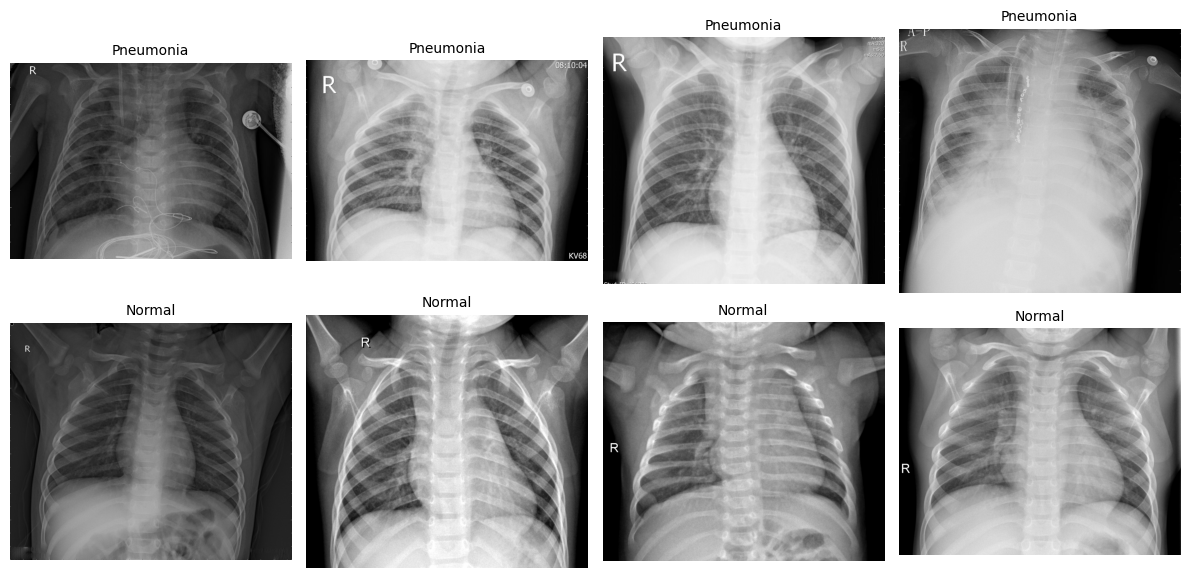

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Create results directory
os.makedirs('/content/results', exist_ok=True)

def visualize_samples(data_dir, split='train', num_samples=4):
    data_path = Path(data_dir) / split
    fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))

    # Pneumonia samples
    pos_dir = data_path / 'positive'
    if pos_dir.exists():
        pos_images = list(pos_dir.glob('*.jpeg')) + list(pos_dir.glob('*.jpg')) + list(pos_dir.glob('*.png'))
        for i, img_path in enumerate(pos_images[:num_samples]):
            img = Image.open(img_path).convert('RGB')
            axes[0, i].imshow(img)
            axes[0, i].set_title('Pneumonia', fontsize=10)
            axes[0, i].axis('off')

    # Normal samples
    neg_dir = data_path / 'negative'
    if neg_dir.exists():
        neg_images = list(neg_dir.glob('*.jpeg')) + list(neg_dir.glob('*.jpg')) + list(neg_dir.glob('*.png'))
        for i, img_path in enumerate(neg_images[:num_samples]):
            img = Image.open(img_path).convert('RGB')
            axes[1, i].imshow(img)
            axes[1, i].set_title('Normal', fontsize=10)
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('/content/results/sample_images.png', dpi=100, bbox_inches='tight')
    plt.show()

visualize_samples('/content/pneumonia_data', split='train', num_samples=4)

## 5. Define Frozen Feature Extractors

In [ ]:
import torch.nn as nn
from torchvision import models

class FrozenResNet50(nn.Module):
    """Frozen ResNet-50 Feature Extractor"""
    def __init__(self):
        super(FrozenResNet50, self).__init__()
        resnet = models.resnet50(weights='IMAGENET1K_V1')

        # Freeze all parameters
        for param in resnet.parameters():
            param.requires_grad = False

        # Remove final FC layer
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x)
        return features.view(features.size(0), -1)


class FrozenDINO(nn.Module):
    """Frozen DINO ViT Feature Extractor"""
    def __init__(self, model_name='dinov2_vits14'):
        super(FrozenDINO, self).__init__()
        self.backbone = torch.hub.load('facebookresearch/dinov2', model_name)

        # Freeze all parameters
        for param in self.backbone.parameters():
            param.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x)
        return features

print("✓ Model classes defined!")

✓ Model classes defined!


## 6. Initialize Models

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print("Initializing models...\n")

# Initialize ResNet-50
print("Loading ResNet-50...")
model_resnet = FrozenResNet50().to(device)
model_resnet.eval()
print("✓ ResNet-50 loaded (2048-dim features)\n")

# Initialize DINO ViT
print("Loading DINO ViT-S/14...")
model_dino = FrozenDINO('dinov2_vits14').to(device)
model_dino.eval()
print("✓ DINO ViT loaded (384-dim features)\n")

print("All models ready!")

Initializing models...

Loading ResNet-50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 144MB/s]


✓ ResNet-50 loaded (2048-dim features)

Loading DINO ViT-S/14...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 143MB/s]


✓ DINO ViT loaded (384-dim features)

All models ready!


## 7. Extract Features - ResNet-50

In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from tqdm import tqdm

# Configuration
CONFIG = {
    'data_dir': '/content/pneumonia_data',
    'output_dir': '/content/results',
    'batch_size': 32,
    'num_workers': 2,
    'img_size': 224,
}

# Feature extraction function
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Extracting'):
            images = images.to(device)
            features = model(images)
            all_features.append(features.cpu())
            all_labels.append(labels)

    return torch.cat(all_features, dim=0), torch.cat(all_labels, dim=0)

# Transforms
transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = datasets.ImageFolder(os.path.join(CONFIG['data_dir'], 'train'), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(CONFIG['data_dir'], 'val'), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(CONFIG['data_dir'], 'test'), transform=transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])

print(f"Datasets loaded:")
print(f"  Train: {len(train_dataset)} images")
print(f"  Val:   {len(val_dataset)} images")
print(f"  Test:  {len(test_dataset)} images\n")

# Extract ResNet-50 features
print("="*70)
print("EXTRACTING RESNET-50 FEATURES")
print("="*70 + "\n")

resnet_features = {}
resnet_labels = {}

for split_name, loader in [('train', train_loader), ('val', val_loader), ('test', test_loader)]:
    print(f"\n{split_name.upper()}:")
    features, labels = extract_features(model_resnet, loader, device)
    resnet_features[split_name] = features
    resnet_labels[split_name] = labels
    print(f"  Features: {features.shape}")
    print(f"  Labels: {labels.shape}")

# Save
torch.save({
    'features': resnet_features,
    'labels': resnet_labels
}, os.path.join(CONFIG['output_dir'], 'resnet50_features.pt'))

print("\n✓ ResNet-50 features saved!")

Datasets loaded:
  Train: 5216 images
  Val:   16 images
  Test:  624 images

EXTRACTING RESNET-50 FEATURES


TRAIN:


Extracting: 100%|██████████| 163/163 [01:25<00:00,  1.91it/s]


  Features: torch.Size([5216, 2048])
  Labels: torch.Size([5216])

VAL:


Extracting: 100%|██████████| 1/1 [00:00<00:00,  2.05it/s]


  Features: torch.Size([16, 2048])
  Labels: torch.Size([16])

TEST:


Extracting: 100%|██████████| 20/20 [00:09<00:00,  2.05it/s]

  Features: torch.Size([624, 2048])
  Labels: torch.Size([624])

✓ ResNet-50 features saved!


## 8. Extract Features - DINO ViT

In [ ]:
# Extract DINO features
print("="*70)
print("EXTRACTING DINO VIT FEATURES")
print("="*70 + "\n")

dino_features = {}
dino_labels = {}

for split_name, loader in [('train', train_loader), ('val', val_loader), ('test', test_loader)]:
    print(f"\n{split_name.upper()}:")
    features, labels = extract_features(model_dino, loader, device)
    dino_features[split_name] = features
    dino_labels[split_name] = labels
    print(f"  Features: {features.shape}")
    print(f"  Labels: {labels.shape}")

# Save
torch.save({
    'features': dino_features,
    'labels': dino_labels
}, os.path.join(CONFIG['output_dir'], 'dino_vit_features.pt'))

print("\n✓ DINO ViT features saved!")

EXTRACTING DINO VIT FEATURES


TRAIN:


Extracting: 100%|██████████| 163/163 [01:19<00:00,  2.06it/s]


  Features: torch.Size([5216, 384])
  Labels: torch.Size([5216])

VAL:


Extracting: 100%|██████████| 1/1 [00:00<00:00,  1.71it/s]


  Features: torch.Size([16, 384])
  Labels: torch.Size([16])

TEST:


Extracting: 100%|██████████| 20/20 [00:09<00:00,  2.13it/s]

  Features: torch.Size([624, 384])
  Labels: torch.Size([624])

✓ DINO ViT features saved!


## 9. Analyze & Visualize Features


ResNet-50 Analysis:
Feature dimension: 2048
Samples: 624
  Normal (0): 234
  Pneumonia (1): 390
Mean: 0.5461
Std: 0.5460


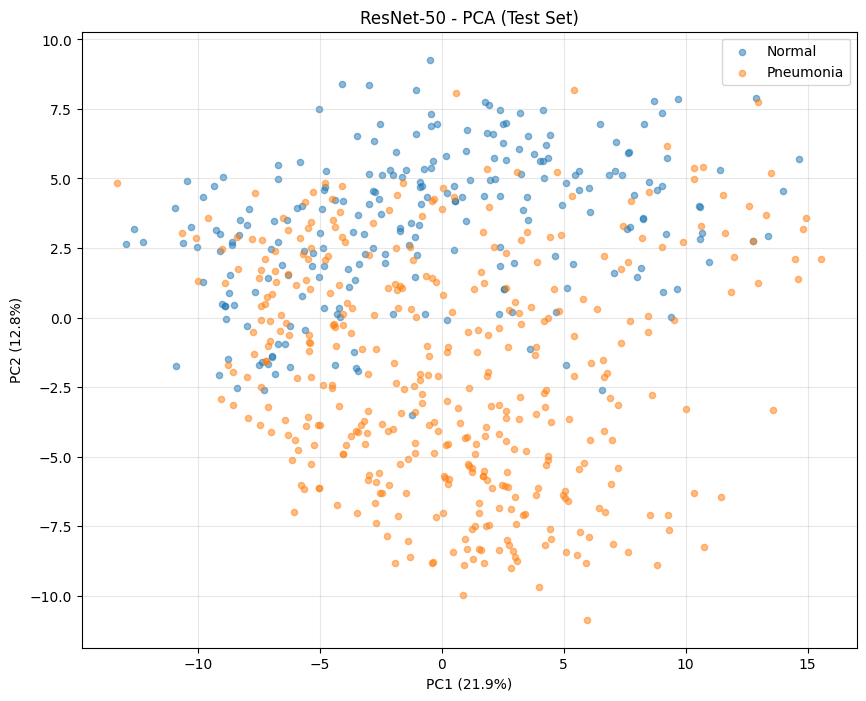


DINO ViT Analysis:
Feature dimension: 384
Samples: 624
  Normal (0): 234
  Pneumonia (1): 390
Mean: 0.0152
Std: 2.4937


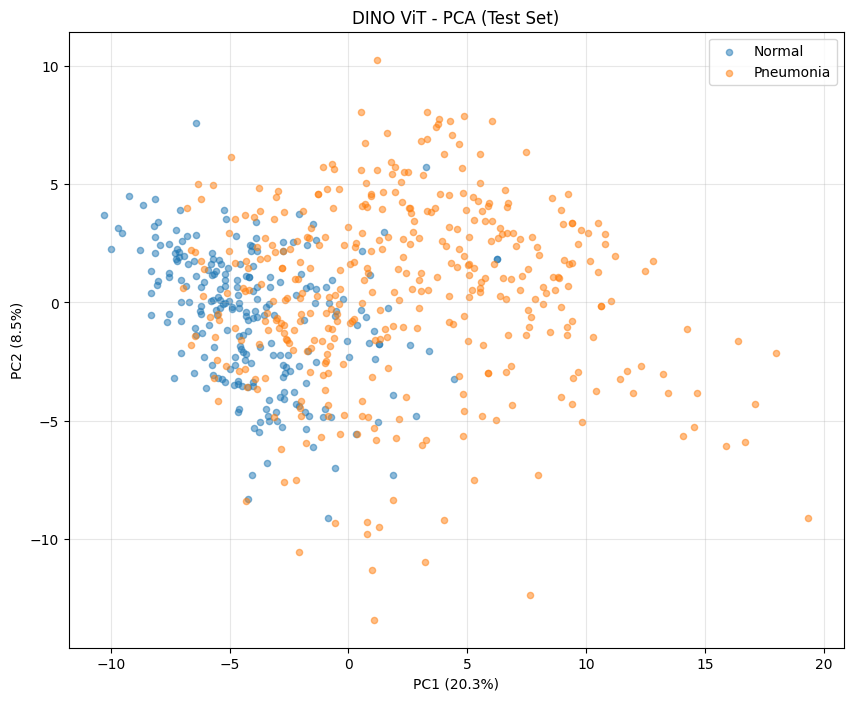

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

def analyze_features(features_dict, labels_dict, model_name):
    features = features_dict['test'].numpy()
    labels = labels_dict['test'].numpy()

    print(f"\n{model_name} Analysis:")
    print("="*60)
    print(f"Feature dimension: {features.shape[1]}")
    print(f"Samples: {features.shape[0]}")
    print(f"  Normal (0): {(labels == 0).sum()}")
    print(f"  Pneumonia (1): {(labels == 1).sum()}")
    print(f"Mean: {features.mean():.4f}")
    print(f"Std: {features.std():.4f}")

    # PCA
    pca = PCA(n_components=2)
    features_2d = pca.fit_transform(features)

    plt.figure(figsize=(10, 8))
    plt.scatter(features_2d[labels == 0, 0], features_2d[labels == 0, 1],
                alpha=0.5, label='Normal', s=20)
    plt.scatter(features_2d[labels == 1, 0], features_2d[labels == 1, 1],
                alpha=0.5, label='Pneumonia', s=20)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title(f'{model_name} - PCA (Test Set)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"/content/results/{model_name.lower().replace(' ', '_')}_pca.png", dpi=150, bbox_inches='tight')
    plt.show()

analyze_features(resnet_features, resnet_labels, "ResNet-50")
analyze_features(dino_features, dino_labels, "DINO ViT")

## 10. Summary

In [ ]:
print("\n" + "="*70)
print("FEATURE EXTRACTION COMPLETE")
print("="*70 + "\n")

print("ResNet-50:")
print(f"  Dimension: {resnet_features['test'].shape[1]}")
print(f"  Train: {resnet_features['train'].shape[0]} samples")
print(f"  Val: {resnet_features['val'].shape[0]} samples")
print(f"  Test: {resnet_features['test'].shape[0]} samples")

print("\nDINO ViT:")
print(f"  Dimension: {dino_features['test'].shape[1]}")
print(f"  Train: {dino_features['train'].shape[0]} samples")
print(f"  Val: {dino_features['val'].shape[0]} samples")
print(f"  Test: {dino_features['test'].shape[0]} samples")

print("\n" + "="*70)
print("\n💾 Saved files:")
print("  - resnet50_features.pt")
print("  - dino_vit_features.pt")
print("  - PCA visualizations")
print("\n✓ Ready for downstream tasks!")
print("="*70)


FEATURE EXTRACTION COMPLETE

ResNet-50:
  Dimension: 2048
  Train: 5216 samples
  Val: 16 samples
  Test: 624 samples

DINO ViT:
  Dimension: 384
  Train: 5216 samples
  Val: 16 samples
  Test: 624 samples


💾 Saved files:
  - resnet50_features.pt
  - dino_vit_features.pt
  - PCA visualizations

✓ Ready for downstream tasks!


## 11. Download Results

In [ ]:
# List files
!ls -lh /content/results/

# Create ZIP
!cd /content && zip -r features.zip results/

print("\n✓ Download 'features.zip' from the file browser!")